# Spartan alpha-selection tutorial for sequencing-based Stereo-seq data

This notebook demonstrates the complete imaging-based Spartan workflow on Stereo-seq samples. The goal is to select a dataset-level value of the graph-mixing parameter $\alpha$, evaluate the selected value on a representative sample, and visualize the resulting Spartan spatial domains against the ground-truth annotations. Ground-truth annotations are used in this tutorial notebook exclusively for benchmarking-oriented parameter analysis and methodological evaluation. Spartan itself remains fully unsupervised during graph construction, graph integration, Leiden clustering, and nLSAS-based configuration pruning. The purpose of the $\alpha$ analysis is to characterize stable dataset-level operating regimes rather than to identify narrowly optimized sample-specific parameters.

The workflow is organized as follows:

1. Load multiple Stereo-seq samples.
2. Preprocess imaging-based spatial transcriptomics data.
3. Build Spartan graphs using KNN spatial neighborhoods.
4. Run the $\alpha$-selection strategy across samples.
5. Derive a consensus $\alpha$ using cross-sample summaries.
6. Evaluate the selected $\alpha$ on one sample across a resolution grid.
7. Report median and best-resolution statistics.
8. Run final Spartan clustering and visualize predicted domains versus ground truth.
9. Visualize the distribution of mean median NMI for candidate $\alpha$ values.
10. Visualize the confusion matrix between the Spartan's domains and the anatomical ground truth labels (Figure 3(C-D) in the paper).

## 1. Import packages and configure plotting

This cell imports the scientific Python stack, the Spartan package, and the metric functions used in this notebook. The fixed random seed improves reproducibility for PCA, Leiden clustering, and any stochastic parts of the workflow. The Scanpy plotting settings are configured so that displayed figures are readable and saved at high resolution.

In [1]:
import scanpy as sc
import spartan as sp
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score
seed = 1

import IPython.display
from matplotlib_inline.backend_inline import set_matplotlib_formats
IPython.display.set_matplotlib_formats = set_matplotlib_formats

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    dpi_save=80,
    facecolor="white",
    frameon=False,
)

/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## 2. Load Stereo-seq samples

Here, nine Stereo-seq `.h5ad` files are loaded as separate `AnnData` objects. These samples are used together for dataset-level alpha selection. In this setup, each object should already contain spatial coordinates in `adata.obsm['spatial']` and ground-truth labels in `adata.obs['ground_truth']`, because the alpha-selection workflow computes supervised benchmarking metrics such as NMI, homogeneity, and completeness.

The nine samples are treated as a small representative cohort for selecting a robust value of $\alpha$ rather than tuning $\alpha$ separately for each sample.

In [ ]:
adata1 = sc.read_h5ad( "/PATH_TO/STEROSEQ/E9.5_E1S1.MOSTA_20250603191448.h5ad")
adata2 = sc.read_h5ad( "/PATH_TO/STEROSEQ/E9.5_E2S1.MOSTA_20250603211748.h5ad")
adata3 = sc.read_h5ad( "/PATH_TO/STEROSEQ/E9.5_E2S2.MOSTA_20250603211807.h5ad")
adata4 = sc.read_h5ad( "/PATH_TO/STEROSEQ/E9.5_E2S3.MOSTA_20250603211812.h5ad")
adata5 = sc.read_h5ad( "/PATH_TO/STEROSEQ/E9.5_E2S4.MOSTA_20250603215907.h5ad")
adata6 = sc.read_h5ad( "/PATH_TO/STEROSEQ/E10.5_E1S1.MOSTA_20250611001833.h5ad")
adata7 = sc.read_h5ad( "/PATH_TO/STEROSEQ/E10.5_E1S2.MOSTA_20250603223724.h5ad")
adata8 = sc.read_h5ad( "/PATH_TO/STEROSEQ/E10.5_E1S3.MOSTA_20250610234230.h5ad")
adata9 = sc.read_h5ad( "/PATH_TO/STEROSEQ/E10.5_E2S1.MOSTA_20250605011342.h5ad")

## 3. Preprocess sequencing-based data

`sp.tl.pre_process_sequencing()` applies the preprocessing routine designed for sequencing-based spatial transcriptomics datasets such as Stereo-seq, 10x Visium, and related spot-based technologies.

Conceptually, this step prepares the `AnnData` object for Spartan graph construction by ensuring that the expression matrix and annotations are in the expected format. This preprocessing is separated from imaging-based preprocessing because sequencing-based datasets cover the entire transcriptome and usually require the highly-variable-gene filtering strategy unlike imaging-based MERFISH, STARmap, or osmFISH data.

Each processed object is stored as `a1` through `a9` and used in the graph-construction step.

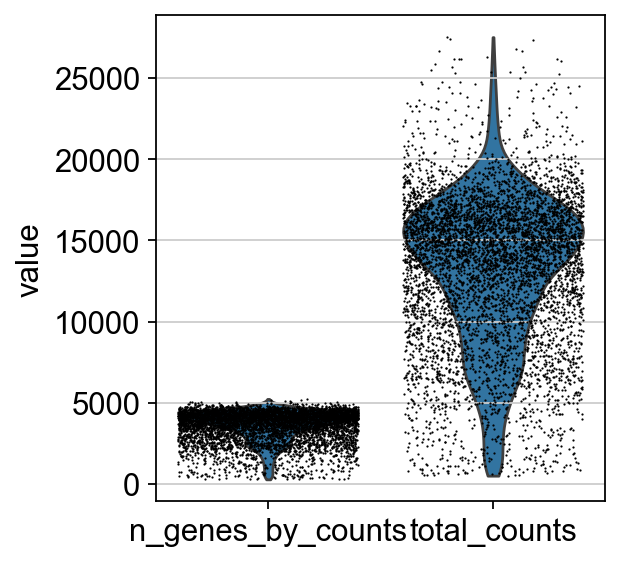

Number of zero-count cells: 0


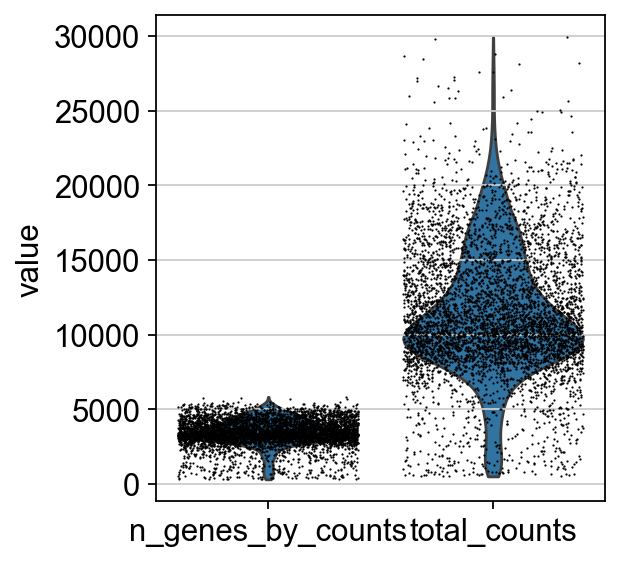

Number of zero-count cells: 0


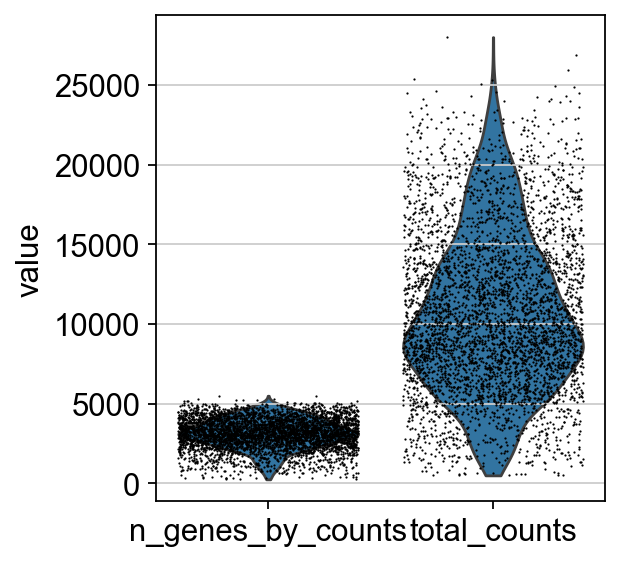

Number of zero-count cells: 0


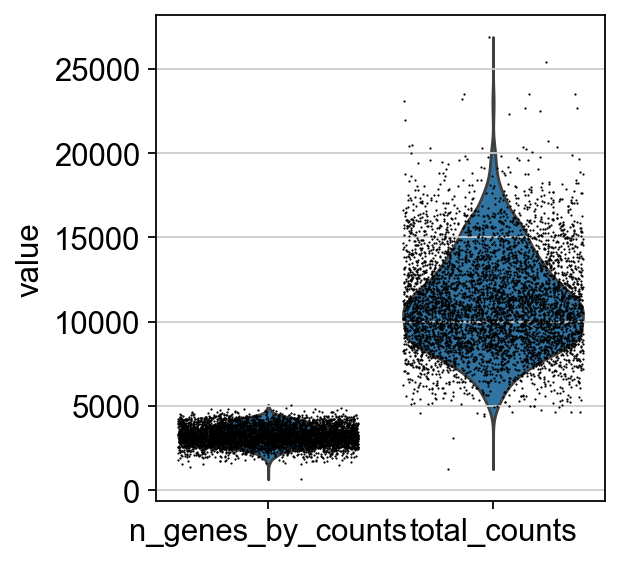

Number of zero-count cells: 0


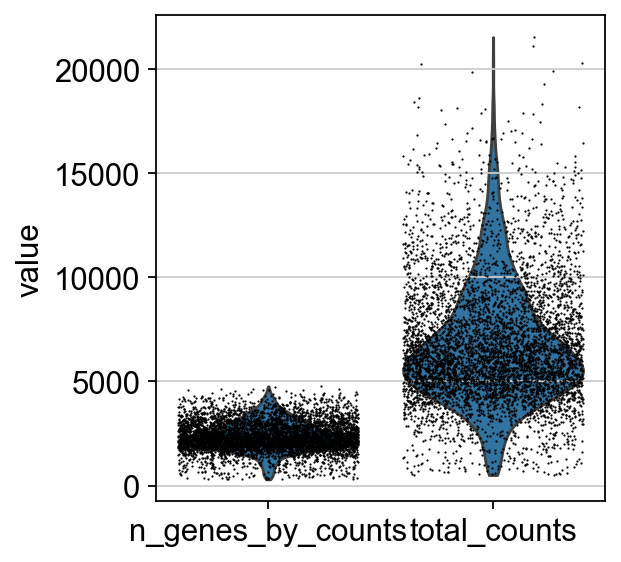

Number of zero-count cells: 0


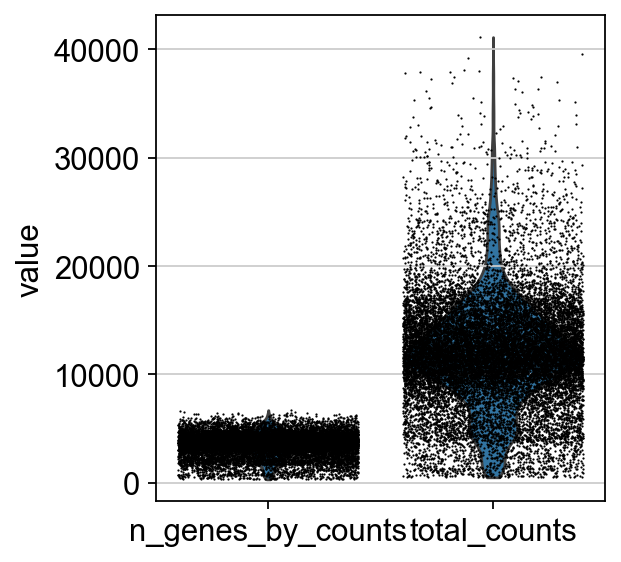

Number of zero-count cells: 0


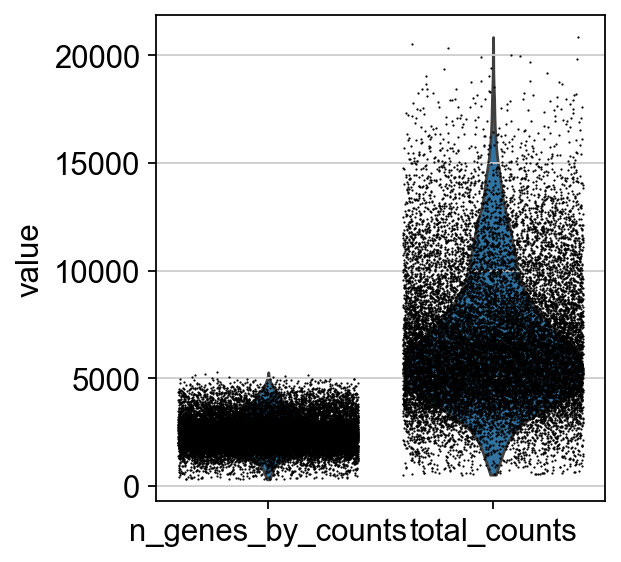

Number of zero-count cells: 0


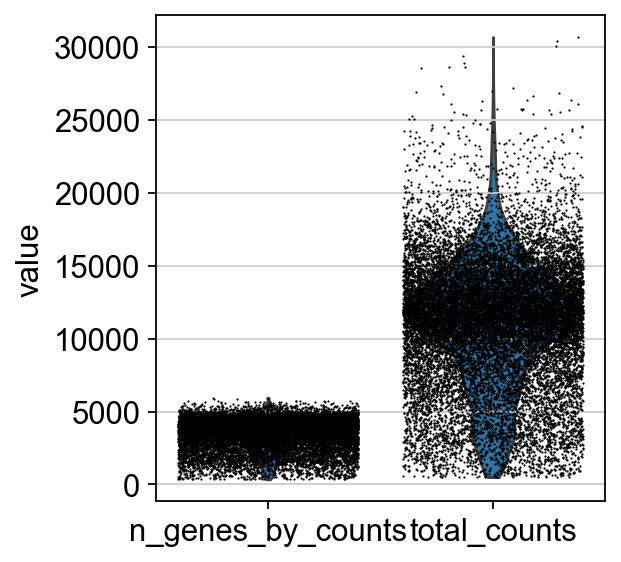

Number of zero-count cells: 0


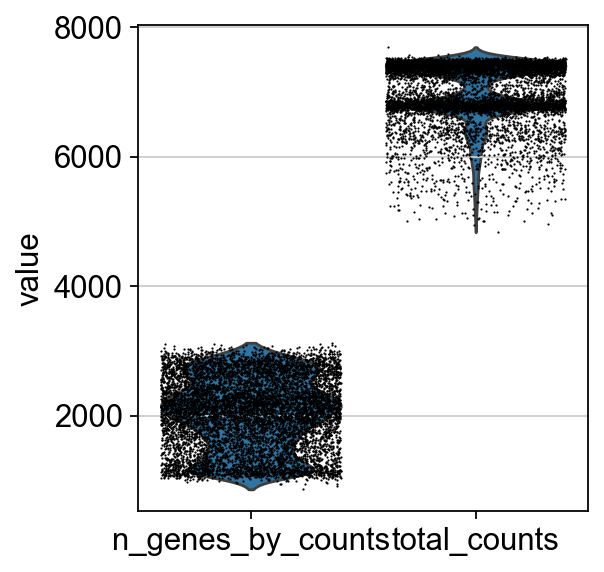

Number of zero-count cells: 0


In [3]:
a1= sp.tl.pre_process_sequencing(adata1)
a2= sp.tl.pre_process_sequencing(adata2)
a3= sp.tl.pre_process_sequencing(adata3)
a4= sp.tl.pre_process_sequencing(adata4)
a5= sp.tl.pre_process_sequencing(adata5)
a6= sp.tl.pre_process_sequencing(adata6)
a7= sp.tl.pre_process_sequencing(adata7)
a8= sp.tl.pre_process_sequencing(adata8)
a9= sp.tl.pre_process_sequencing(adata9)

## 4. Build Spartan graphs using KNN spatial neighborhoods

This cell builds the three core Spartan graph components for each sample using a **K-nearest-neighbor graph** with `spatial_neighs=4` and `spatial_rings=1` for spatial and LSA graphs, and `spatial_neighs=15` for gene expression connectivity graph:

- `spartan_spatial_graph`: binary spatial adjacency graph $S$.
- `spartan_spatial_weights`: row-normalized inverse-distance spatial weights.
- `spartan_lsa_graph`: Local Spatial Activation graph $L$.
- `spartan_gene_graph`: gene expression connectivity graph $G$ built in PCA space.

The function `sp.tl.spartan_build_graphs()` computes PCA internally, constructs the spatial graph, builds the LSA graph, and then constructs the gene expression connectivity graph. Because `copy=True`, the original preprocessed objects `a1` to `a9` are preserved, while the graph-augmented objects are returned as `ad1` to `ad9`. KNN graphs often provide more stable neighborhood sizes across samples. Since, this is a grid data, it uses `spatial_coord = "grid"` for spatial and LSA graphs. 

Again, the returned graph-augmented objects are named `ad1` to `ad9`. 

In [4]:
ad1= sp.tl.spartan_build_graphs(adata=a1,spatial_coord="grid",spatial_neighs=4,spatial_rings=1,spatial_neighborhood="knn",copy=True)
ad2= sp.tl.spartan_build_graphs(adata=a2,spatial_coord="grid",spatial_neighs=4,spatial_rings=1,spatial_neighborhood="knn",copy=True)
ad3= sp.tl.spartan_build_graphs(adata=a3,spatial_coord="grid",spatial_neighs=4,spatial_rings=1,spatial_neighborhood="knn",copy=True)
ad4= sp.tl.spartan_build_graphs(adata=a4,spatial_coord="grid",spatial_neighs=4,spatial_rings=1,spatial_neighborhood="knn",copy=True)
ad5= sp.tl.spartan_build_graphs(adata=a5,spatial_coord="grid",spatial_neighs=4,spatial_rings=1,spatial_neighborhood="knn",copy=True)
ad6= sp.tl.spartan_build_graphs(adata=a6,spatial_coord="grid",spatial_neighs=4,spatial_rings=1,spatial_neighborhood="knn",copy=True)
ad7= sp.tl.spartan_build_graphs(adata=a7,spatial_coord="grid",spatial_neighs=4,spatial_rings=1,spatial_neighborhood="knn",copy=True)
ad8= sp.tl.spartan_build_graphs(adata=a8,spatial_coord="grid",spatial_neighs=4,spatial_rings=1,spatial_neighborhood="knn",copy=True)
ad9= sp.tl.spartan_build_graphs(adata=a9,spatial_coord="grid",spatial_neighs=4,spatial_rings=1,spatial_neighborhood="knn",copy=True)

/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/v16847mf/miniforge3/envs/spar

## 5. Run alpha selection independently for each sample

`sp.tl.initiate_alpha_selection()` performs the core Spartan alpha-selection sweep for a single sample. For each candidate $\alpha$ (Here, $\beta_1$ and $\beta_2$ are set to default: 0.26 and 0.24) , it builds the aggregated graph

$$
J = (\alpha - \beta_1)L + (1 - \alpha)G + (\alpha - \beta_2)S,
$$

then runs Leiden clustering and evaluates the predicted domains against `adata.obs['ground_truth']`.

In this notebook:

- $\alpha$ is swept from `0.5` to `0.9` in steps of `0.01` (default).
- Leiden resolution is swept from `0.5` to `0.9` in steps of `0.01` (default).
- `config='lsg'` means the full Spartan graph combination is used: LSA graph + spatial graph + gene expression connectivity graph (default).
- `use_nLSAS=True` applies the nLSAS-based pruning strategy.
- `lower_nlsas=40` and `upper_nlsas=70` retain solutions within the selected nLSAS percentile band (default).
- `n_jobs=8` parallelizes the search (default).

The output for each sample is a summary table that records performance statistics for each alpha after resolution-level aggregation/pruning.

In [5]:
%%time
summary_a1 = sp.tl.initiate_alpha_selection(adata=ad1,lower_alpha=0.5,upper_alpha=0.9,step_alpha=0.01,
                                     lower_resolution=0.5,upper_resolution=1.2,step_resolution=0.01,
                                     lower_nlsas=40,upper_nlsas=70,n_jobs=16,config="lsg",seed=seed,use_nLSAS=True)

summary_a2 = sp.tl.initiate_alpha_selection(adata=ad2,lower_alpha=0.5,upper_alpha=0.9,step_alpha=0.01,
                                     lower_resolution=0.5,upper_resolution=1.2,step_resolution=0.01,
                                     lower_nlsas=40,upper_nlsas=70,n_jobs=16,config="lsg",seed=seed,use_nLSAS=True)

summary_a3 = sp.tl.initiate_alpha_selection(adata=ad3,lower_alpha=0.5,upper_alpha=0.9,step_alpha=0.01,
                                     lower_resolution=0.5,upper_resolution=1.2,step_resolution=0.01,
                                     lower_nlsas=40,upper_nlsas=70,n_jobs=16,config="lsg",seed=seed,use_nLSAS=True)

summary_a4 = sp.tl.initiate_alpha_selection(adata=ad4,lower_alpha=0.5,upper_alpha=0.9,step_alpha=0.01,
                                     lower_resolution=0.5,upper_resolution=1.2,step_resolution=0.01,
                                     lower_nlsas=40,upper_nlsas=70,n_jobs=16,config="lsg",seed=seed,use_nLSAS=True)

summary_a5 = sp.tl.initiate_alpha_selection(adata=ad5,lower_alpha=0.5,upper_alpha=0.9,step_alpha=0.01,
                                     lower_resolution=0.5,upper_resolution=1.2,step_resolution=0.01,
                                     lower_nlsas=40,upper_nlsas=70,n_jobs=16,config="lsg",seed=seed,use_nLSAS=True)

summary_a6 = sp.tl.initiate_alpha_selection(adata=ad6,lower_alpha=0.5,upper_alpha=0.9,step_alpha=0.01,
                                     lower_resolution=0.5,upper_resolution=1.2,step_resolution=0.01,
                                     lower_nlsas=40,upper_nlsas=70,n_jobs=16,config="lsg",seed=seed,use_nLSAS=True)

summary_a7 = sp.tl.initiate_alpha_selection(adata=ad7,lower_alpha=0.5,upper_alpha=0.9,step_alpha=0.01,
                                     lower_resolution=0.5,upper_resolution=1.2,step_resolution=0.01,
                                     lower_nlsas=40,upper_nlsas=70,n_jobs=16,config="lsg",seed=seed,use_nLSAS=True)

summary_a8 = sp.tl.initiate_alpha_selection(adata=ad8,lower_alpha=0.5,upper_alpha=0.9,step_alpha=0.01,
                                     lower_resolution=0.5,upper_resolution=1.2,step_resolution=0.01,
                                     lower_nlsas=40,upper_nlsas=70,n_jobs=16,config="lsg",seed=seed,use_nLSAS=True)

summary_a9 = sp.tl.initiate_alpha_selection(adata=ad9,lower_alpha=0.5,upper_alpha=0.9,step_alpha=0.01,
                                     lower_resolution=0.5,upper_resolution=1.2,step_resolution=0.01,
                                     lower_nlsas=40,upper_nlsas=70,n_jobs=16,config="lsg",seed=seed,use_nLSAS=True)

/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/v16847mf/miniforge3/envs/spartan-paperS/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configurati

CPU times: user 37.9 s, sys: 2.3 s, total: 40.2 s
Wall time: 31min 1s


## 6. Collect per-sample alpha-selection summaries

The five alpha-selection summary tables are collected into a list. This list is the input to the cross-sample consensus step. Keeping each sample summary separate is important because the goal is not to optimize one sample in isolation, but to find an alpha value that performs robustly across the dataset.

In [6]:
summary = [summary_a1,summary_a2,summary_a3,summary_a4,summary_a5,summary_a6,summary_a7,summary_a8,summary_a9]

## 7. Compute consensus alpha across samples

`sp.tl.consensus_alpha()` combines the per-sample alpha-selection summaries and ranks candidate alpha values according to cross-sample performance. Here, `top_k=50` means that the top 50 (default) best-performing alpha candidates from each sample summary are considered when computing consensus support.

The selected value is stored as `best_alpha`. This value is intended to be used as a dataset-level Spartan parameter for downstream domain identification.

In [7]:
combined = sp.tl.consensus_alpha(summary, top_k=50)
best_alpha = combined.iloc[0]["alpha"]
print(best_alpha)

0.56


## 8. Inspect the consensus-alpha ranking table

The `combined` table contains the cross-sample alpha ranking. This table is useful for checking whether the selected alpha is clearly supported or whether several nearby alpha values perform similarly. This table shows that alpha was selected at the dataset level rather than tuned separately for individual samples.

In [8]:
combined

,alpha,median_NMI_s1,median_NMI_s2,median_NMI_s3,median_NMI_s4,median_NMI_s5,median_NMI_s6,median_NMI_s7,median_NMI_s8,median_NMI_s9,mean_median_NMI
0,0.56,0.610903,0.640116,0.698242,0.682659,0.620762,0.619159,0.464883,0.611903,0.650941,0.622174
1,0.58,0.613425,0.639812,0.695368,0.658769,0.623350,0.622469,0.475221,0.611170,0.648047,0.620848
2,0.55,0.604447,0.642432,0.686376,0.664360,0.619288,0.621200,0.476400,0.607253,0.665742,0.620833
3,0.64,0.607933,0.645243,0.683701,0.676972,0.626119,0.627188,0.461034,0.604745,0.651365,0.620478
4,0.57,0.614540,0.642865,0.691715,0.661413,0.622227,0.617905,0.468110,0.612872,0.646168,0.619757
5,0.53,0.574290,0.638245,0.703546,0.665707,0.614895,0.633627,0.455913,0.613193,0.665131,0.618283
6,0.59,0.603986,0.635379,0.687436,0.664823,0.619459,0.632739,0.456755,0.608544,0.653810,0.618103
7,0.60,0.588940,0.645804,0.689330,0.673801,0.623391,0.623042,0.463687,0.599270,0.649849,0.617457
8,0.62,0.573752,0.645279,0.677033,0.666385,0.622522,0.620408,0.471735,0.609867,0.660408,0.616377
9,0.65,0.582487,0.639311,0.676079,0.691512,0.626557,0.589531,0.459958,0.607930,0.659817,0.614798


## 9. Extract graph components from the evaluation sample

This section evaluates the selected `best_alpha` on one sample Stereo-seq E9.5E2S2, here `ad3`. The three Spartan graph components are extracted from `ad3.obsp`:

- `lsa_graph`: Local Spatial Activation graph $L$.
- `gene_graph`: gene expression connectivity graph $G$.
- `spatial_graph`: spatial adjacency graph $S$.

These are the graph components that will be mixed using the selected alpha value and scanned over the resolution grid.

In [9]:
lsa_graph = ad3.obsp['spartan_lsa_graph']
gene_graph = ad3.obsp['spartan_gene_graph']
spatial_graph = ad3.obsp['spartan_spatial_graph']

## 10. Build an igraph cache for efficient resolution scanning

`sp.tl.build_graph_cache()` converts the sparse Spartan graph components into cached edge-weight arrays and an igraph object. This avoids repeatedly reconstructing the graph from scratch during alpha and resolution sweeps.

The cache usually contains:

- `graph`: the igraph object used by Leiden.
- `w_lsa`: cached LSA edge weights.
- `w_gene`: cached gene-graph edge weights.
- `w_spatial`: cached spatial-graph edge weights.

This caching step is important for speed, especially when scanning many alpha and resolution combinations.

In [10]:
graph_cache = sp.tl.build_graph_cache(lsa_graph=lsa_graph,gene_graph=gene_graph,spatial_graph=spatial_graph)

## 11. Prepare the resolution grid and nLSAS values for the selected sample

This cell defines the Leiden resolution grid for evaluating the selected `best_alpha` on `ad3`. The resolution parameter controls the granularity of the detected spatial domains: lower values generally produce fewer/larger clusters, while higher values produce more/finer clusters.

The cell also extracts cached edge weights and computes local spatial activation values using `sp.tl.local_spatial_activation()`. The resulting `spartan_local_spatial_activation` values are used to compute nLSAS, which acts as an intrinsic Spartan spatial-coherence criterion for filtering candidate partitions.

In [11]:
lower_resolution = 0.5
upper_resolution=1.2
step_resolution=0.01
resolution_grid = np.arange(lower_resolution, upper_resolution, step_resolution)
resolution_grid = np.round(np.asarray(resolution_grid, dtype=float), 3)
w_lsa = graph_cache['w_lsa']
w_gene = graph_cache['w_gene']
w_spatial = graph_cache['w_spatial']
config='lsg'
alpha=best_alpha
true_labels=np.asarray(ad3.obs["ground_truth"])
sp.tl.local_spatial_activation(ad3,lsa_graph)
nLSAS_values = np.asarray(ad3.obs["spartan_local_spatial_activation"])

## 12. Evaluate the selected alpha across the resolution grid

`sp.tl.process_alpha_light()` evaluates a fixed alpha value across the resolution grid using the cached graph and edge weights. For each resolution, Leiden clustering is run on the aggregated graph, and the resulting partition is compared to the ground-truth labels.

The output contains one record per resolution, typically including metrics such as NMI, homogeneity, completeness, and nLSAS when `use_nLSAS=True`.

In [12]:
df_results = sp.tl.process_alpha_light(alpha,graph_cache['graph'],resolution_grid,config,true_labels,
                                       seed,w_lsa,w_gene,w_spatial,nLSAS_values,use_nLSAS=True)

## 13. Convert resolution-sweep results to a DataFrame

The result returned by `process_alpha_light()` is converted into a pandas DataFrame for easier filtering, summarization, and plotting. Each row represents one candidate resolution for the fixed selected alpha.

In [13]:
df_results=pd.DataFrame(df_results)

In [14]:
df_results

,alpha,resolution,ClusterN,NMI,HOM,COM,nLSAS
0,0.56,0.50,8,0.681116,0.610612,0.770027,0.443375
1,0.56,0.51,8,0.680361,0.605687,0.776036,0.400786
2,0.56,0.52,9,0.691918,0.634109,0.761324,0.346736
3,0.56,0.53,9,0.688359,0.625985,0.764538,0.346633
4,0.56,0.54,9,0.700206,0.639518,0.773620,0.406971
...,...,...,...,...,...,...,...
65,0.56,1.15,14,0.705382,0.706457,0.704311,0.328710
66,0.56,1.16,13,0.678705,0.679144,0.678267,0.429970
67,0.56,1.17,13,0.689977,0.683088,0.697005,0.292618
68,0.56,1.18,13,0.685213,0.687507,0.682934,0.317917


## 14. Prune candidate resolutions using nLSAS

`sp.tl.prune_results_nLSAS()` filters candidate clustering solutions according to the nLSAS percentile range. Here, solutions between the 40th and 70th percentile of nLSAS are retained.

This step is used to avoid selecting partitions that are either too weakly spatially coherent or potentially over-smoothed. In this workflow, nLSAS is applied within the Spartan L+S+G configuration as an intrinsic coherence filter.

In [15]:
lower_nLSAS_percentile=40
upper_nLSAS_percentile=70
df_pruned = sp.tl.prune_results_nLSAS(ad3,df_results,alpha,lower_nLSAS_percentile,upper_nLSAS_percentile)

In [16]:
df_pruned

,alpha,resolution,ClusterN,NMI,HOM,COM,nLSAS
60,0.56,1.10,13,0.691658,0.692749,0.690571,0.319225
62,0.56,1.12,13,0.701635,0.703060,0.700216,0.327859
64,0.56,1.14,13,0.696708,0.697903,0.695517,0.321453
69,0.56,1.19,13,0.699775,0.696427,0.703154,0.338844


## 15. Compute median performance statistics after nLSAS pruning

The median statistics summarize the typical performance of the selected alpha across the retained resolution range. Reporting median values is useful because it avoids relying on a single resolution and gives a more stable picture of performance.

Here, the notebook summarizes:

- `NMI`: normalized mutual information.
- `HOM`: homogeneity.
- `COM`: completeness.
- `nLSAS`: normalized Local Spatial Activation Score.

In [17]:
median_stats = df_pruned[["NMI", "HOM", "COM", "nLSAS"]].median(axis=0)

In [18]:
df_pruned

,alpha,resolution,ClusterN,NMI,HOM,COM,nLSAS
60,0.56,1.10,13,0.691658,0.692749,0.690571,0.319225
62,0.56,1.12,13,0.701635,0.703060,0.700216,0.327859
64,0.56,1.14,13,0.696708,0.697903,0.695517,0.321453
69,0.56,1.19,13,0.699775,0.696427,0.703154,0.338844


## 16. Selection of representative visualization configuration

To visualize representative Spartan spatial domains, we selected the configuration with the highest ARI among the nLSAS-pruned configurations. Importantly, ARI was not used during $\alpha$-selection, graph construction, clustering, or nLSAS-based pruning.

Median statistics across the pruned configuration set were used as the primary robustness summary, while the best-ARI configuration was used for representative spatial domain visualization.

In [19]:
beta1=0.26
beta2=0.24
key_added = "spartan_domains"
ari_scores = []
for alpha,resolution in zip(df_pruned["alpha"],df_pruned["resolution"]):
    sp.tl.perform_leiden_clustering(ad3,lsa_graph,spatial_graph,gene_graph,
                              alpha,beta1,beta2,resolution,seed,key_added)
    ARI = adjusted_rand_score(true_labels, ad3.obs['spartan_domains'])
    ari_scores.append(ARI)


df_pruned["ARI"] = ari_scores

## 17. Identify the best single-resolution configuration

`best_config` selects the retained resolution with the highest ARI. This gives the best-performing single configuration for the selected sample after nLSAS pruning.

The median statistics and best configuration answer two slightly different questions:

- `median_stats`: how robustly the selected alpha performs across resolutions.
- `best_config`: the best single resolution under this alpha for this sample.

In [20]:
best_config = df_pruned.loc[df_pruned["ARI"].idxmax()]

## 18. Display median statistics

This cell prints the median post-pruning statistics. These values are useful for reporting stable sample-level performance and for comparing Spartan against alternative methods across a resolution range.

In [21]:
median_stats

NMI      0.698242
HOM      0.697165
COM      0.697867
nLSAS    0.324656
dtype: float64

## 19. Display the best configuration

This cell displays the best single retained resolution according to ARI. The resulting row should include the selected alpha, resolution, performance metrics, and nLSAS value for that solution.

In [22]:
best_config

alpha          0.560000
resolution     1.190000
ClusterN      13.000000
NMI            0.699775
HOM            0.696427
COM            0.703154
nLSAS          0.338844
ARI            0.566468
Name: 69, dtype: float64

## 20. Inspect the graph-augmented AnnData object

This cell displays the `ad3` object after Spartan graph construction and local spatial activation computation. At this stage, the object should contain Spartan graph matrices in `ad3.obsp` and local activation values in `ad3.obs`.

In [23]:
ad3

AnnData object with n_obs × n_vars = 4321 × 19736
    obs: 'annotation', 'leiden', 'Region', 'ground_truth', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'n_counts', 'spartan_local_spatial_activation', 'spartan_leiden', 'spartan_domains'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'annotation_colors', 'leiden', 'leiden_colors', 'moranI', 'neighbors', 'pca', 'spatial_neighbors', 'umap', 'log1p', 'hvg', 'spatial_graph_neighbors', 'gene_graph_neighbors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'raw', 'log1pX'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances', 'spatial_graph_connectivities'

## 21. Run final Spartan spatial-domain identification on the selected sample

`sp.tl.spartan_spatial_domains()` runs the full Spartan domain-identification wrapper on `ad3`. This wrapper rebuilds the required graphs and then performs Leiden clustering using the specified alpha, beta values, and resolution.

In the current cell, alpha and resolution are entered explicitly. The alpha is the best_alpha and the resolution is the resolution of the best configuration (best_config).

Also ensure that `spatial_neighborhood` matches the graph configuration used during alpha selection. If the alpha-selection summaries came from the KNN graph-building cell, use `spatial_neighborhood="knn"`,`spatial_neighs=4`, `spatial_rings = 1` and `spatial_coord = "grid"`.

Because `copy=True`, the final AnnData object is returned as `ad3_sp`, while the original `ad3` remains unchanged.

In [24]:
ad3_sp= sp.tl.spartan_spatial_domains(adata=ad3,
    spatial_coord = "grid",
    spatial_neighs=4,
    spatial_rings=1,                                  
    spatial_neighborhood = "knn",
    total_pca_comps = 50,
    pca_comps_extract = 30,
    gene_coord = "generic",
    gene_neighs = 15,
    alpha = 0.56,
    beta1 = 0.26,
    beta2 = 0.24,
    resolution = 1.19,
    seed = 1,
    key_added = "spartan_domains",
    copy = True)

## 22. Inspect the final Spartan-clustered AnnData object

The returned object `ad3_sp` should now contain the predicted Spartan domains in `ad3_sp.obs['spartan_domains']`, along with the Spartan graph matrices stored in `ad3_sp.obsp`.

In [25]:
ad3_sp

AnnData object with n_obs × n_vars = 4321 × 19736
    obs: 'annotation', 'leiden', 'Region', 'ground_truth', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'n_counts', 'spartan_local_spatial_activation', 'spartan_leiden', 'spartan_domains'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'annotation_colors', 'leiden', 'leiden_colors', 'moranI', 'neighbors', 'pca', 'spatial_neighbors', 'umap', 'log1p', 'hvg', 'spatial_graph_neighbors', 'gene_graph_neighbors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'raw', 'log1pX'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances', 'spatial_graph_connectivities'

## 23. Visualize Spartan spatial domains

This cell plots the spatial distribution of the predicted Spartan domains. The visual output shows that Spartan can accurately recover anatomically coherent and spatially contiguous regions.

/home/v16847mf/Downloads/spartan-st-mainT/spartan-st-main/src/spartan/pl.py:29: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=color, ax=ax, title=title, show=False, **kwargs)


<Axes: title={'center': 'Spartan'}, xlabel='spatial1', ylabel='spatial2'>

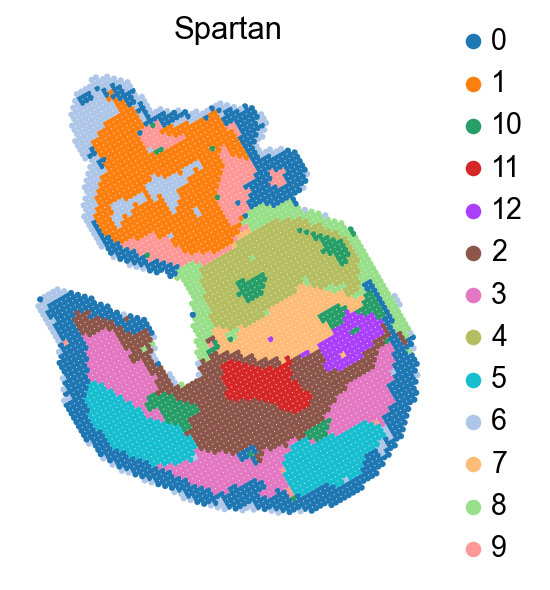

In [26]:
sp.pl.spatial_domains(adata =  ad3_sp, img_key=None,
    color="spartan_domains",
    wspace=0.3,
    title="Spartan",
    size=2.5,
    spot_size=0.5)

## 24. Visualize ground-truth domains

This cell plots the ground-truth spatial annotations for the same sample. Comparing this plot with the Spartan domain plot helps assess whether Spartan recovers the expected anatomical organization and where disagreements occur.

/home/v16847mf/Downloads/spartan-st-mainT/spartan-st-main/src/spartan/pl.py:29: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=color, ax=ax, title=title, show=False, **kwargs)


<Axes: title={'center': 'Ground_Truth'}, xlabel='spatial1', ylabel='spatial2'>

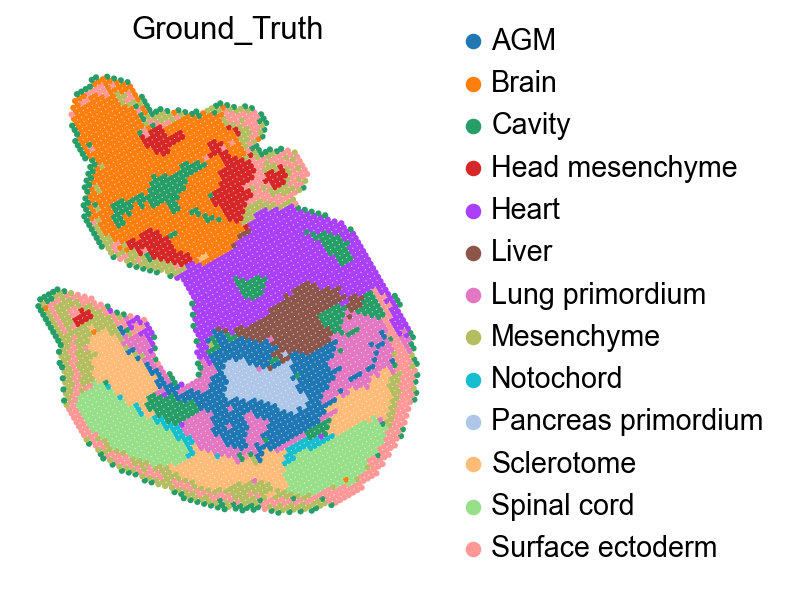

In [27]:
sp.pl.spatial_domains(adata =  ad3_sp, img_key=None,
    color="ground_truth",
    wspace=0.3,
    title="Ground_Truth",
    size=2.5,
    spot_size=0.5)

## 25. Save top 50 $\alpha$ consensus values

In [28]:
combined.to_csv("StereoSeqSDMAlphaStrategy.csv")

## 26. Plots show mean median normalized mutual information (NMI) across nine samples as a function of candidate $\alpha$ values retained in the consensus set 

Stereo-seq exhibited a stable consensus $\alpha$ regime at lower $\alpha$ values than MERFISH, suggesting that sequencing-based spatial transcriptomics benefits from a more balanced integration of local activation, spatial adjacency, and expression connectivity.

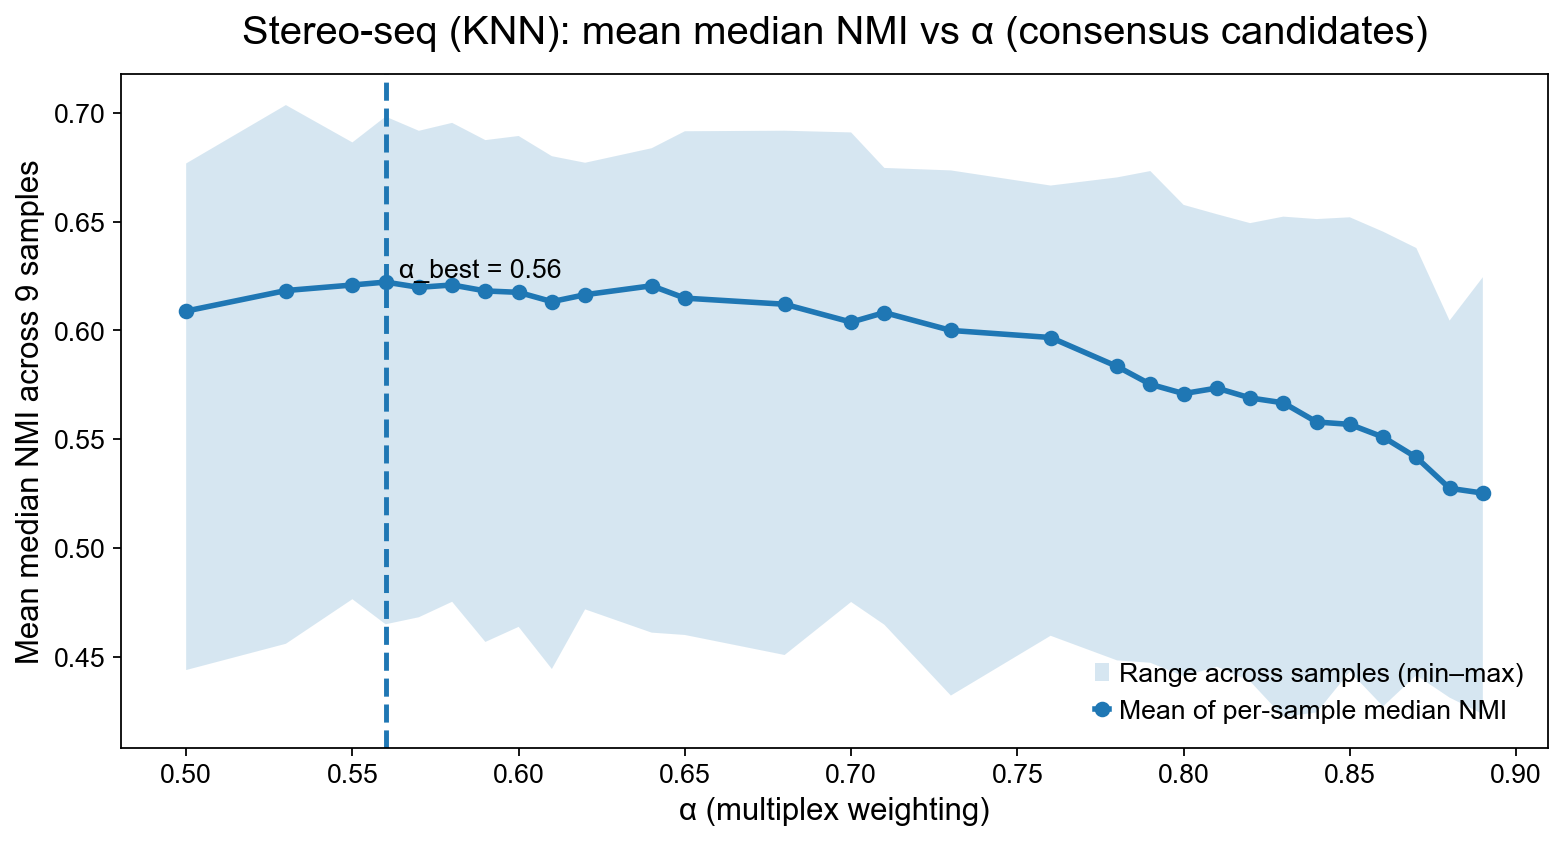

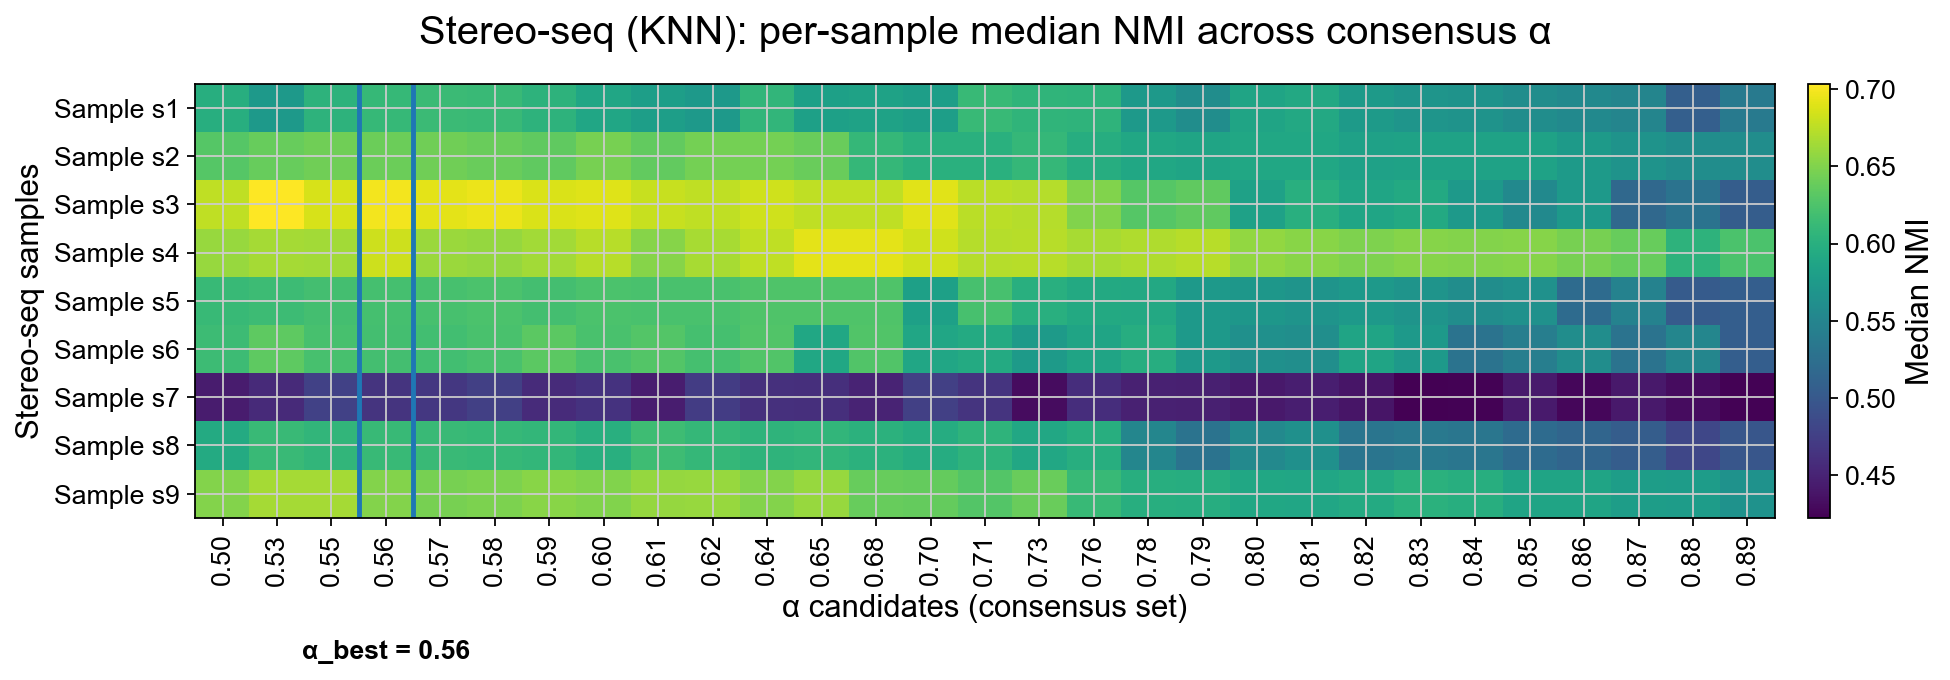

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Inputs
# -------------------------
CSV_PATH = "StereoSeqSDMAlphaStrategy.csv"   # change if needed
OUT_CURVE = "Stereo-seq_alpha_mean_median_curveDelau.pdf"
OUT_HEAT  = "Stereo-seq_alpha_per_sample_heatmapDelau.pdf"

# -------------------------
# Load + sanitize
# -------------------------
df = pd.read_csv(CSV_PATH)

# drop common index column 
for col in ["Unnamed: 0", "index"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Required columns
assert "alpha" in df.columns, "CSV must contain an 'alpha' column."
assert "mean_median_NMI" in df.columns, "CSV must contain 'mean_median_NMI'."

sample_cols = [c for c in df.columns if c.startswith("median_NMI_")]
assert len(sample_cols) > 0, "No columns found matching 'median_NMI_*'."

# Sort by alpha 
df = df.sort_values("alpha").reset_index(drop=True)

alphas = df["alpha"].to_numpy()
y_mean = df["mean_median_NMI"].to_numpy()
y_min  = df[sample_cols].min(axis=1).to_numpy()
y_max  = df[sample_cols].max(axis=1).to_numpy()

# alpha_best
alpha_best = float(df.loc[df["mean_median_NMI"].idxmax(), "alpha"])
best_val   = float(df["mean_median_NMI"].max())

# -------------------------
# Style knobs 
# -------------------------
TITLE_FZ = 18
LABEL_FZ = 14
TICK_FZ  = 12
LEG_FZ   = 12
ANN_FZ   = 12

# -------------------------
# Figure 1: mean median NMI vs alpha
# -------------------------
plt.figure(figsize=(10, 5.5))

plt.fill_between(alphas, y_min, y_max, alpha=0.18, label="Range across samples (min–max)")
plt.plot(alphas, y_mean, marker="o", linewidth=2.5, label="Mean of per-sample median NMI")

plt.axvline(alpha_best, linestyle="--", linewidth=2.2)
plt.text(alpha_best + (alphas.max() - alphas.min()) * 0.01, best_val,
         f"α_best = {alpha_best:.2f}", fontsize=ANN_FZ, va="bottom")

plt.title("Stereo-seq (KNN): mean median NMI vs α (consensus candidates)", fontsize=TITLE_FZ, pad=14)
plt.xlabel("α (multiplex weighting)", fontsize=LABEL_FZ)
plt.ylabel("Mean median NMI across 9 samples", fontsize=LABEL_FZ)

plt.xticks(fontsize=TICK_FZ)
plt.yticks(fontsize=TICK_FZ)
plt.legend(fontsize=LEG_FZ, frameon=False, loc="lower right")
plt.grid(False)
plt.tight_layout()

plt.show()

# -------------------------
# Figure 2: per-sample heatmap across alpha  
# -------------------------
mat = df[sample_cols].T  # rows: samples, cols: alpha

plt.figure(figsize=(12.5, 4.8))  
im = plt.imshow(mat.to_numpy(), aspect="auto")

plt.title(
    "Stereo-seq (KNN): per-sample median NMI across consensus α",
    fontsize=TITLE_FZ,
    pad=18  
)
plt.xlabel("α candidates (consensus set)", fontsize=LABEL_FZ)
plt.ylabel("Stereo-seq samples", fontsize=LABEL_FZ)

plt.xticks(
    ticks=np.arange(len(alphas)),
    labels=[f"{a:.2f}" for a in alphas],
    rotation=90,
    fontsize=TICK_FZ
)
plt.yticks(
    ticks=np.arange(len(sample_cols)),
    labels=[c.replace("median_NMI_", "Sample ") for c in sample_cols],
    fontsize=TICK_FZ
)

# Highlight alpha_best column
best_idx = int(np.where(np.isclose(alphas, alpha_best))[0][0])
plt.axvline(best_idx - 0.5, linewidth=2.2)
plt.axvline(best_idx + 0.5, linewidth=2.2)


plt.annotate(
    f"α_best = {alpha_best:.2f}",
    xy=(best_idx, 0), xycoords=("data", "axes fraction"),
    xytext=(0, -55), textcoords="offset points",
    ha="center", va="top",
    fontsize=ANN_FZ,
    fontweight="bold"
)

# Colorbar
cbar = plt.colorbar(im, fraction=0.028, pad=0.02)
cbar.set_label("Median NMI", fontsize=LABEL_FZ)
cbar.ax.tick_params(labelsize=TICK_FZ)


plt.tight_layout()
plt.subplots_adjust(bottom=0.30)


plt.show()



## 27. Confusion matrix analysis between Spartan domains and anatomical ground truth labels

To further assess the anatomical consistency of Spartan-derived spatial domains, we generate a contingency heatmap between predicted Spartan clusters and annotated anatomical labels for the Stereo-seq E9.5E2S2 sample. 

A contingency matrix is first constructed between the predicted Spartan domains and the ground-truth anatomical annotations. The matrix is then row-normalized to emphasize the relative distribution of predicted clusters within each anatomical region. To obtain an interpretable one-to-one correspondence between predicted and anatomical domains, the Hungarian assignment algorithm is applied to the normalized contingency matrix. This procedure identifies an optimal mapping between predicted clusters and ground-truth labels by maximizing overall agreement.

The reordered contingency matrix is subsequently visualized as a high-resolution heatmap, where stronger diagonal structure indicates improved anatomical alignment between Spartan domains and reference annotations. Predicted clusters are then relabeled according to the optimal Hungarian assignment and projected back onto tissue coordinates for direct spatial comparison against the anatomical ground truth.

The two figures shown below are also shown in Figure 3(C-D) in the paper.

In [30]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import scanpy as sc
import numpy as np
from scipy.optimize import linear_sum_assignment

# ---------------------- Register Arial ----------------------
arial_files = [
    "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf",
    "/usr/share/fonts/truetype/msttcorefonts/arialbd.ttf",
    "/usr/share/fonts/truetype/msttcorefonts/arialbi.ttf",
    "/usr/share/fonts/truetype/msttcorefonts/ariali.ttf"
]
for f in arial_files:
    if os.path.exists(f):
        fm.fontManager.addfont(f)
arial_name = fm.FontProperties(fname=arial_files[0]).get_name()

plt.rcParams.update({
    "font.family": arial_name,
    "font.size": 60
})

def match_relabel_and_plot_clean(
    adata,
    ground_truth_col="ground_truth",
    pred_col="Spartan",
    matched_col="spartan_matched",
    normalize="row",
    annotate_policy=None,
    save_prefix="GT_vs_Pred",
    heatmap_figsize=(26, 14),   
    spatial_spot_size=1.5,
):
    """
    Publication-ready contingency heatmap (Arial, large font sizes, no gridlines).
    Hungarian assignment ensures alignment of predicted to GT clusters.
    """

    # 1) contingency
    contingency = pd.crosstab(adata.obs[ground_truth_col], adata.obs[pred_col])

    # 2) normalize
    if normalize == "row":
        contingency_norm = contingency.div(contingency.sum(axis=1), axis=0)
    elif normalize == "col":
        contingency_norm = contingency.div(contingency.sum(axis=0), axis=1)
    else:
        contingency_norm = contingency.copy()

    # 3) Hungarian assignment
    cost_matrix = -contingency_norm.values
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    mapping = {contingency.columns[j]: contingency.index[i] for i, j in zip(row_ind, col_ind)}

    # 4) reorder
    new_row_order = [contingency.index[i] for i in row_ind]
    new_col_order = [contingency.columns[j] for j in col_ind]
    contingency_norm_diag = contingency_norm.loc[new_row_order, new_col_order]

    # 5) plot heatmap
    fig, ax = plt.subplots(figsize=heatmap_figsize)

    im = ax.imshow(
        contingency_norm_diag.values,
        aspect='auto',
        interpolation='nearest',
        cmap='BuPu',
    )

    # ticks and labels
    ax.set_xticks(np.arange(contingency_norm_diag.shape[1]))
    ax.set_xticklabels(contingency_norm_diag.columns, rotation=0, ha="center", fontsize=38)
    ax.set_yticks(np.arange(contingency_norm_diag.shape[0]))
    ax.set_yticklabels(contingency_norm_diag.index, fontsize=38)

    # remove spines and ticks
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(which='both', length=0)

    # colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=38, length=0)

    # labels and title
    ax.set_xlabel("Predicted clusters", fontsize=50, labelpad=20, weight="bold")
    ax.set_ylabel("Ground truth clusters", fontsize=50, labelpad=20, weight="bold")
    ax.set_title("Ground Truth vs Predicted Cluster Mapping", fontsize=56, pad=30, weight="bold")

    plt.tight_layout()
    heatmap_path = f"{save_prefix}_heatmap.pdf"
    fig.savefig(heatmap_path, dpi=600, bbox_inches="tight")
    plt.show()

    # 6) matched labels
    pred_as_str = adata.obs[pred_col].astype(str)
    matched = pred_as_str.map(mapping).fillna("unassigned")
    try:
        gt_labels = list(adata.obs[ground_truth_col].cat.categories)
    except Exception:
        gt_labels = sorted(adata.obs[ground_truth_col].unique().astype(str).tolist())
    categories = gt_labels + (["unassigned"] if "unassigned" in matched.values else [])
    adata.obs[matched_col] = pd.Categorical(matched, categories=categories, ordered=True)

    # 7) spatial plots
    sc.pl.spatial(
        adata,
        color=ground_truth_col,
        spot_size=spatial_spot_size,
        title="Ground Truth",
        show=False
    )
    plt.savefig(f"{save_prefix}_spatial_GT.pdf", dpi=600, bbox_inches="tight")
    plt.show()
    
    sc.pl.spatial(
        adata,
        color=matched_col,
        spot_size=spatial_spot_size,
        title="Predicted (Matched to GT)",
        show=False
    )
    plt.savefig(f"{save_prefix}_spatial_matched.pdf", dpi=600, bbox_inches="tight")
    plt.show()

    return {
        "mapping": mapping,
        "contingency": contingency,
        "contingency_norm": contingency_norm_diag,
        "heatmap_path": heatmap_path,
        "spatial_gt_path": f"{save_prefix}_spatial_GT.pdf",
        "spatial_matched_path": f"{save_prefix}_spatial_matched.pdf",
    }


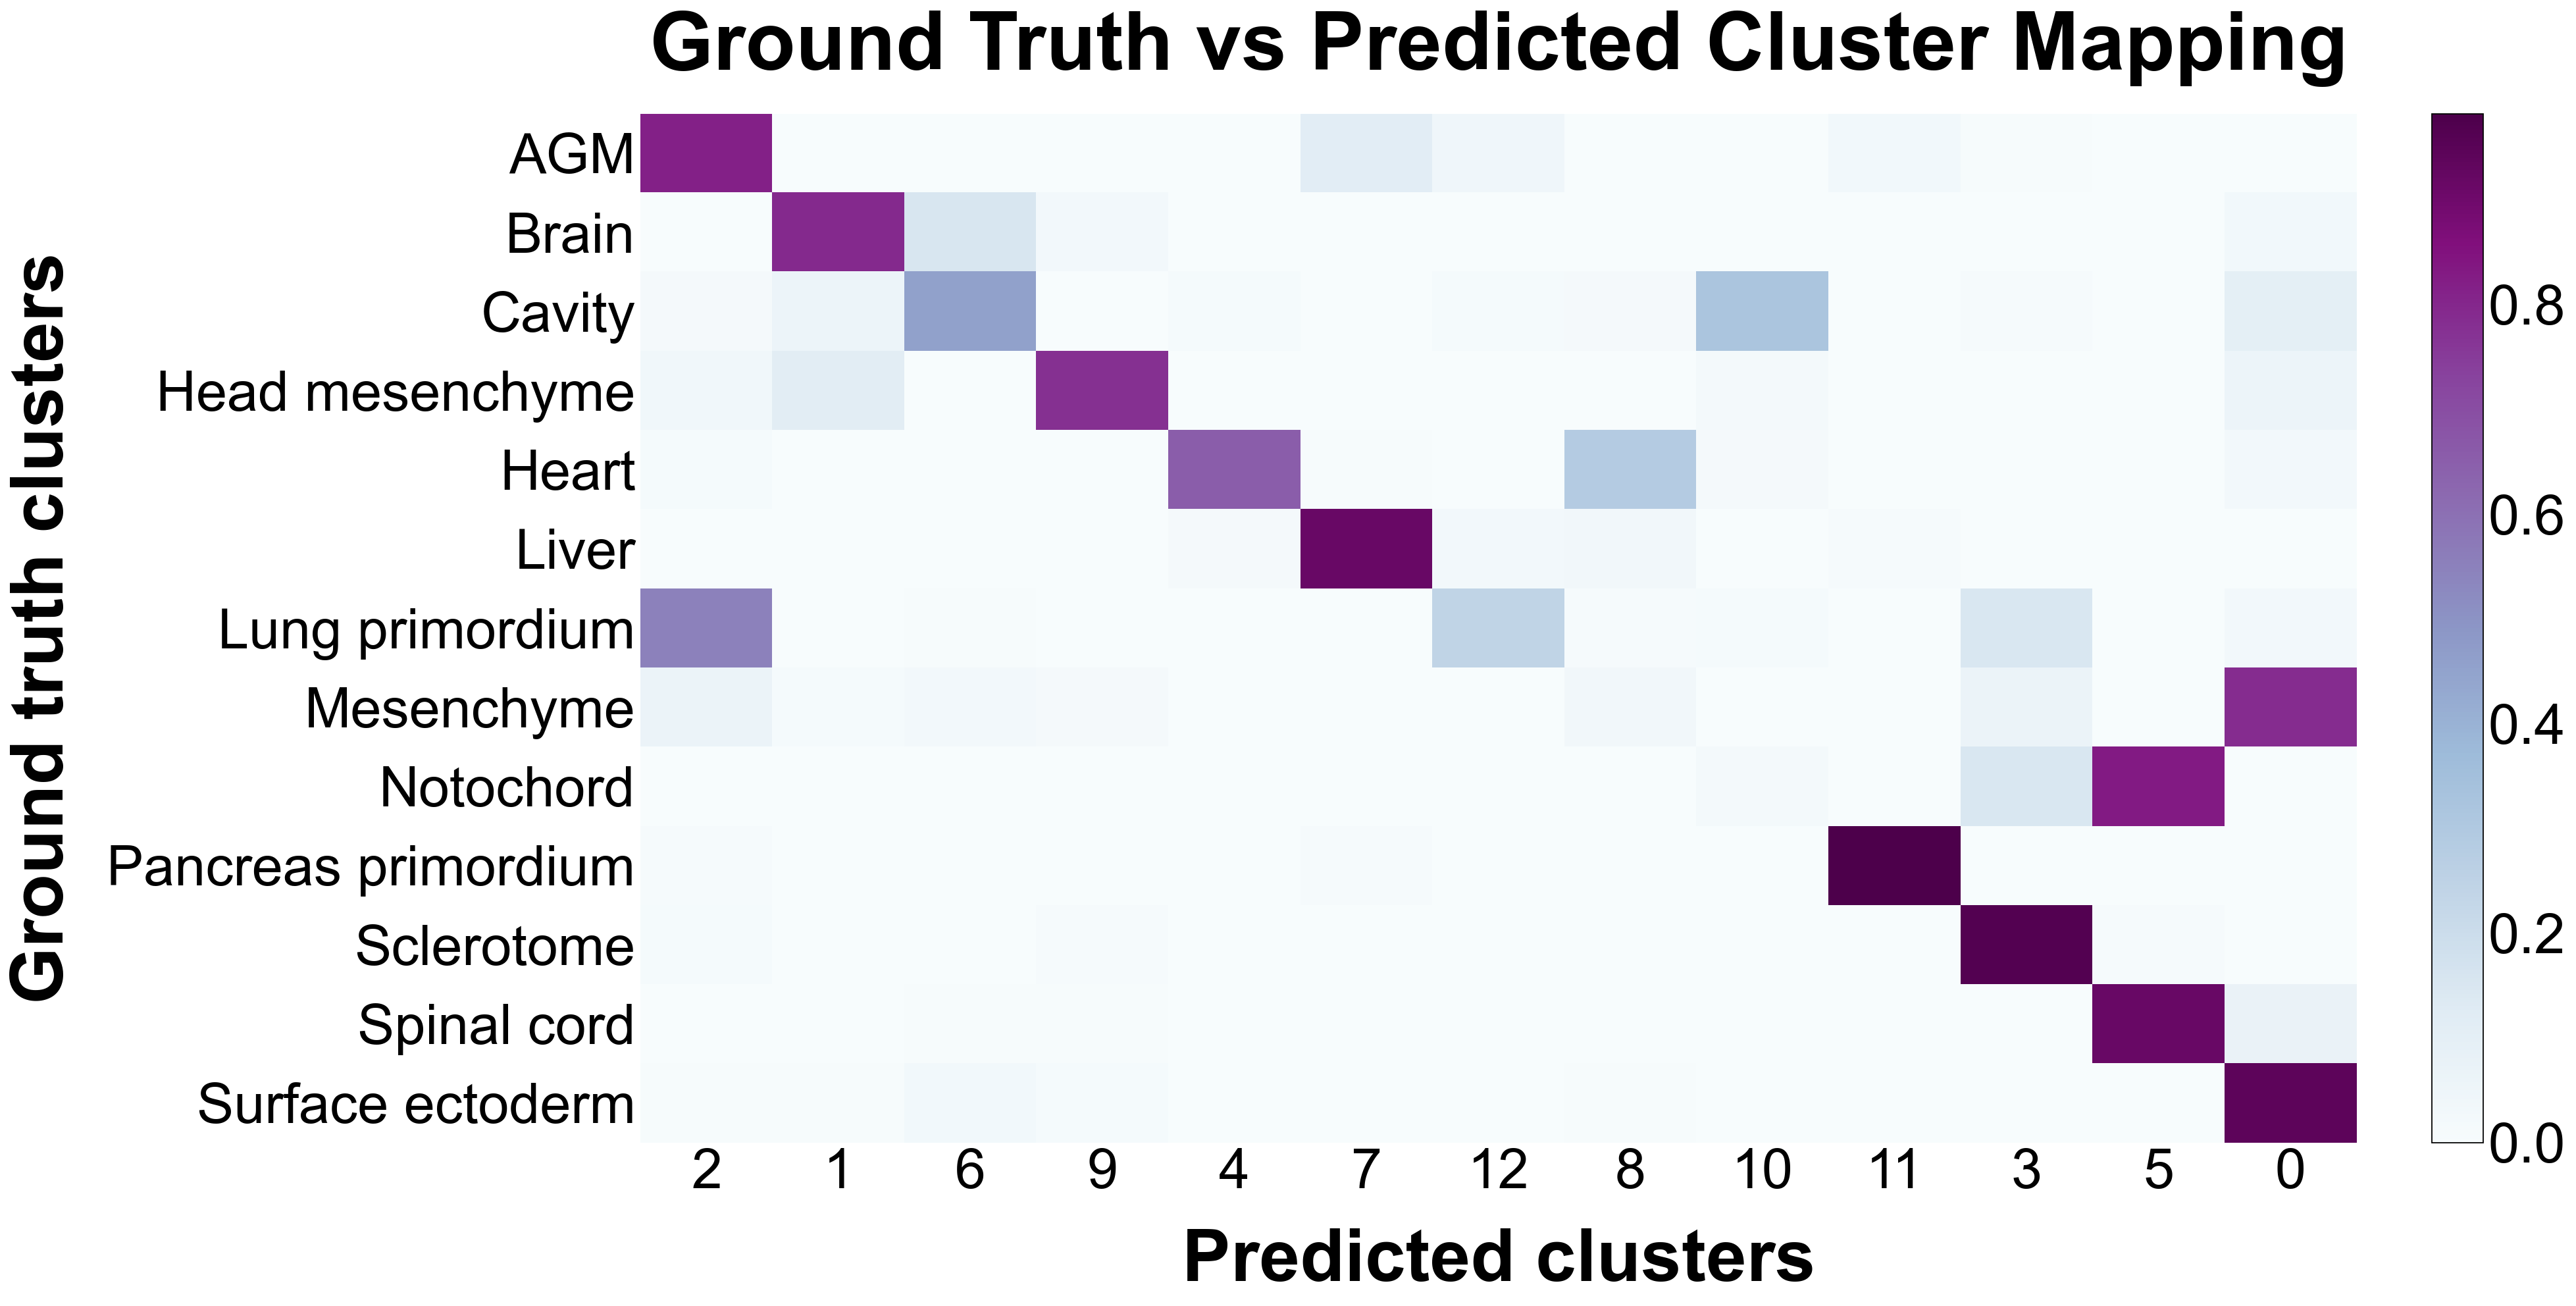

/tmp/ipykernel_314766/2160170360.py:112: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


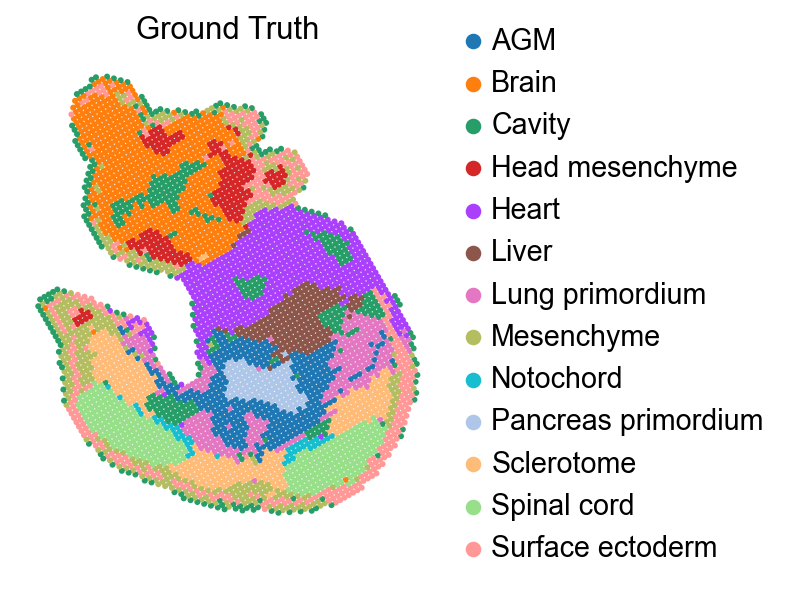

/tmp/ipykernel_314766/2160170360.py:122: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


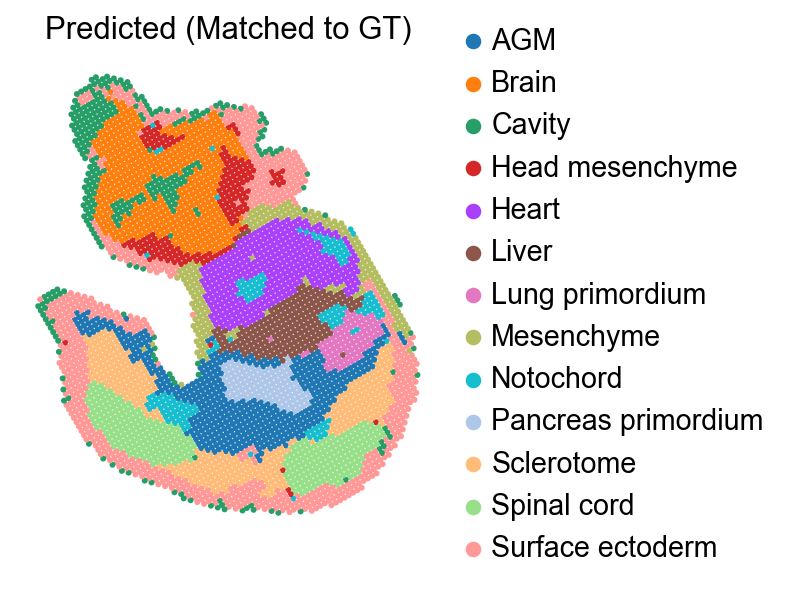

Mapping (spartan → ground_truth):
{'2': 'AGM', '1': 'Brain', '6': 'Cavity', '9': 'Head mesenchyme', '4': 'Heart', '7': 'Liver', '12': 'Lung primordium', '8': 'Mesenchyme', '10': 'Notochord', '11': 'Pancreas primordium', '3': 'Sclerotome', '5': 'Spinal cord', '0': 'Surface ectoderm'}


In [31]:
results = match_relabel_and_plot_clean(
    ad3_sp,
    ground_truth_col="ground_truth",
    pred_col="spartan_domains",
    matched_col="spartan_matched",
    normalize="row",
    annotate_policy=None,   # clean annotations
    save_prefix="GT_vs_Spartan",
    spatial_spot_size=1.2
)

print("Mapping (spartan → ground_truth):")
print(results["mapping"])

## Summary

Spartan identified stable graph integration regimes across nine Stereo-seq samples, with consensus $\alpha$ values stabilizing within a moderate $\alpha$ range compared to imaging-based datasets. The resulting activation-aware partitions demonstrated strong agreement with anatomical annotations while remaining robust across neighboring $\alpha$ values and resolution configurations.